In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 가상 비선형 데이터 생성

In [210]:
# 가상 데이터 생성 (y = 0.5 * x^2 + x + noise)
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 1) * 4 - 2 # 약간의 비선형을 보이기 위해 임의의 값을 추가 연산
Y = 0.5 * X**2 + X + np.random.randn(n_samples, 1) * 0.5

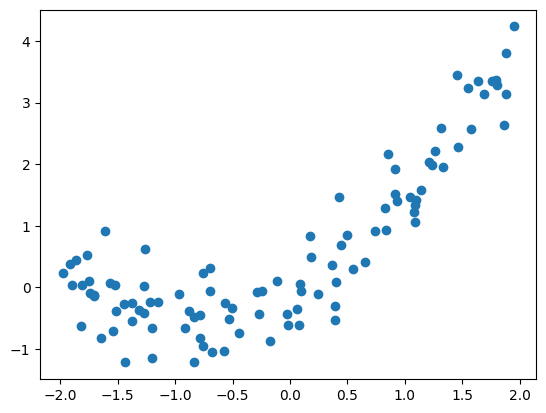

In [211]:
plt.scatter(X, Y)

Text(0.5, 0, 'X2')

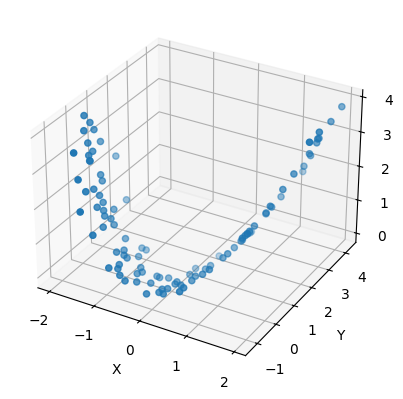

In [212]:
X2 = X ** 2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X, Y, X2)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("X2")

## 다항 회귀 모델 설정

In [213]:
# 2차항 까지 확장 (시각화를 위해서, 본래라면 더 높은 차수로 올라가야함)
degree = 2
poly = PolynomialFeatures(degree=degree)
X_poly = poly.fit_transform(X) # 얘는 특징 추출만 함
model = LinearRegression().fit(X_poly, Y)


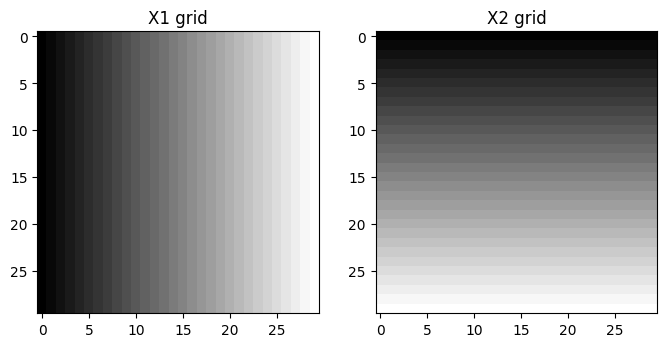

In [214]:
# 3D 시각화를 위한 격자 생성
X1_range = np.linspace(-5, 5, 30)
X2_range = np.linspace(-5, 5, 30)
X1_grid, X2_grid = np.meshgrid(X1_range, X2_range)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("X1 grid")
plt.imshow(X1_grid, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("X2 grid")
plt.imshow(X2_grid, cmap='gray')

In [215]:
grid_points = np.c_[X1_grid.ravel(), X2_grid.ravel()]

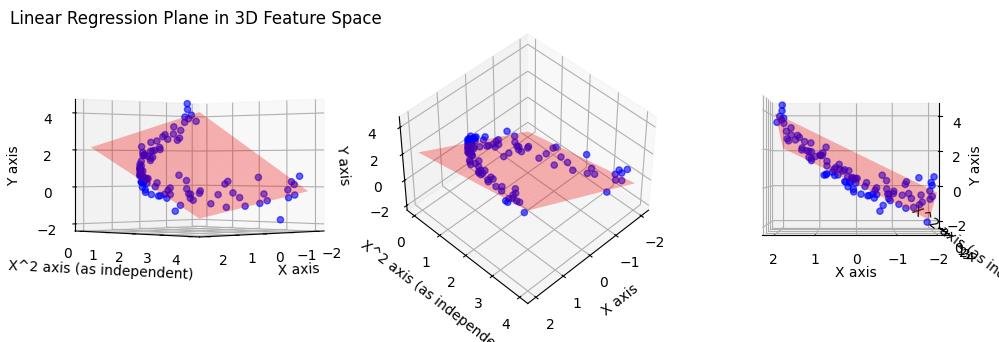

In [216]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. 데이터 준비
n_samples = 100
X = np.sort(np.random.rand(n_samples, 1) * 4 - 2, axis=0)
X2 = X**2  # X의 제곱항을 별도의 피처로 간주
Y = 0.5 * X2 + 1.0 * X + np.random.randn(n_samples, 1) * 0.5

# 모델 학습 (X와 X2를 두 개의 독립 변수로 입력)
features = np.hstack([X, X2])
model = LinearRegression()
model.fit(features, Y)

# 2. 평면(Plane)을 그리기 위한 격자 데이터 생성
x_range = np.linspace(-2, 2, 20)
x2_range = np.linspace(0, 4, 20) # X^2의 범위 (0~4)
X_grid, X2_grid = np.meshgrid(x_range, x2_range)

# 평면의 예측값 계산: Y = w1*X + w2*X2 + b
Y_grid = model.coef_[0, 0] * X_grid + model.coef_[0, 1] * X2_grid + model.intercept_


# 3. 시각화
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')


# 실제 데이터 포인트
ax.view_init(elev=0, azim=45)
ax.scatter(X, X2, Y, color='blue', label='Actual Data Points', alpha=0.6)

ax2.view_init(elev=45, azim=45)
ax2.scatter(X, X2, Y, color='blue', label='Actual Data Points', alpha=0.6)

ax3.view_init(elev=0, azim=90)
ax3.scatter(X, X2, Y, color='blue', label='Actual Data Points', alpha=0.6)

# 회귀 평면 (Surface)
ax.plot_surface(X_grid, X2_grid, Y_grid, color='red', alpha=0.3, label='Regression Plane')
ax2.plot_surface(X_grid, X2_grid, Y_grid, color='red', alpha=0.3, label='Regression Plane')
ax3.plot_surface(X_grid, X2_grid, Y_grid, color='red', alpha=0.3, label='Regression Plane')

ax.set_xlabel('X axis')
ax.set_ylabel('X^2 axis (as independent)')
ax.set_zlabel('Y axis')
ax2.set_xlabel('X axis')
ax2.set_ylabel('X^2 axis (as independent)')
ax2.set_zlabel('Y axis')
ax3.set_xlabel('X axis')
ax3.set_ylabel('X^2 axis (as independent)')
ax3.set_zlabel('Y axis')
ax.set_title('Linear Regression Plane in 3D Feature Space')

plt.show()

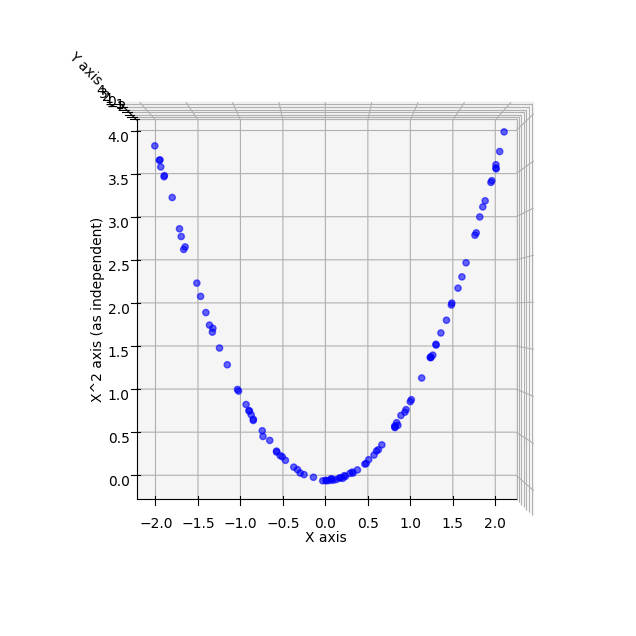

In [217]:
def poly_3Ddraw(
        ax,
        data:list,
        surface:list,
        elev,
        azim
):
    X, X2, Y = data
    X_grid, X2_grid, Y_grid = surface

    ax.view_init(elev=elev, azim=azim)
    ax.scatter(X, X2, Y, color='blue', label='Actual Data Points', alpha=0.6)

    # 회귀 평면 (Surface)
    # ax.plot_surface(X_grid, X2_grid, Y_grid, color='red', alpha=0.3, label='Regression Plane')

    ax.set_xlabel('X axis')
    ax.set_ylabel('X^2 axis (as independent)')
    ax.set_zlabel('Y axis')

    return ax

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax = poly_3Ddraw(ax,
            data=[X, X2, Y],
            surface=[X_grid, X2_grid, Y_grid],
            elev=90,
            azim=-90)

# plt.show()


<Axes3D: xlabel='X axis', ylabel='X^2 axis (as independent)', zlabel='Y axis'>

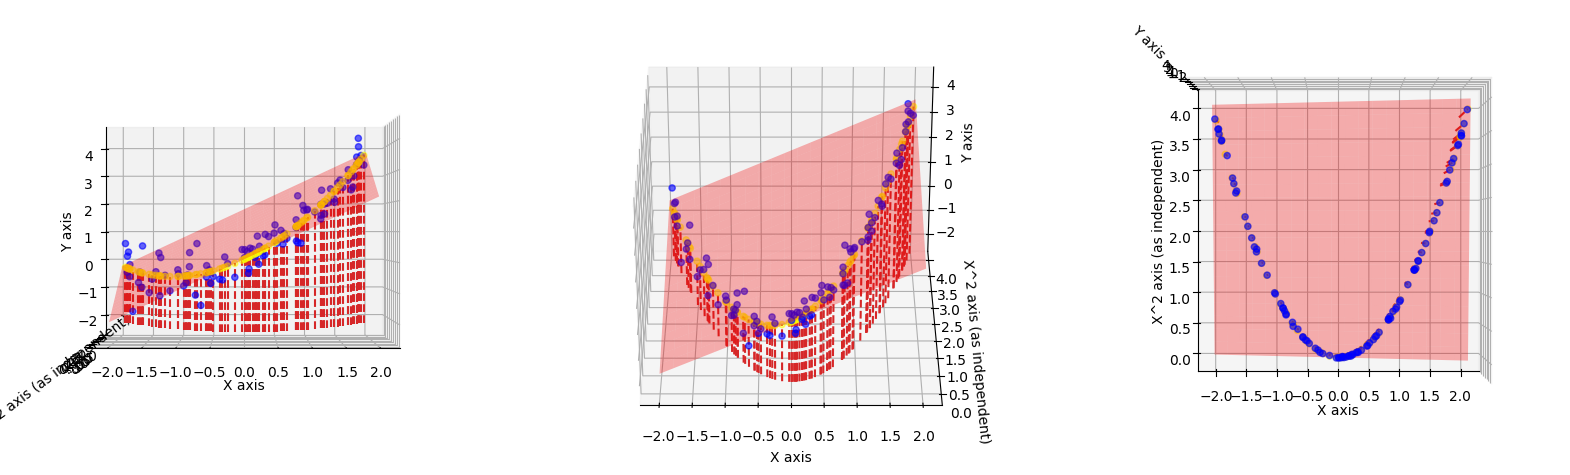

In [218]:
def poly_3Ddraw_points(
        ax,
        data:list,
        model,
        surface:list,
        elev,
        azim
):
    X, X2, Y = data
    X_grid, X2_grid, Y_grid = surface

    feaures = np.hstack([X, X2])
    Y_pred = model.predict(feaures)

    ax.view_init(elev=elev, azim=azim)
    ax.scatter(X, X2, Y, color='blue', label='Actual Data Points', alpha=0.6)

    points = np.hstack([X, X2, Y_pred])

    # x, y, z 각 축의 범위를 가져옴
    z_limits = ax.get_zlim()  # (zmin, zmax) 반환
    zmin = z_limits[0]

    for i in points:
        ax.plot([i[0], i[0]] ,[i[1], i[1]], [zmin, i[2]], color='tab:red', linestyle='--')

    ax.scatter(X, X2, Y_pred, color="yellow", alpha=0.5)

    # 회귀 평면 (Surface)
    ax.plot_surface(X_grid, X2_grid, Y_grid, color='red', alpha=0.3, label='Regression Plane')

    ax.set_xlabel('X axis')
    ax.set_ylabel('X^2 axis (as independent)')
    ax.set_zlabel('Y axis')

    return ax

fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot(131, projection='3d')
ax = poly_3Ddraw_points(ax,
            data=[X, X2, Y],
            surface=[X_grid, X2_grid, Y_grid],
            model=model,
            elev=0,
            azim=-90)

ax2 = fig.add_subplot(132, projection='3d')
poly_3Ddraw_points(ax2,
            data=[X, X2, Y],
            surface=[X_grid, X2_grid, Y_grid],
            model=model,
            elev=30,
            azim=-90)

ax3 = fig.add_subplot(133, projection='3d')
poly_3Ddraw_points(ax3,
            data=[X, X2, Y],
            surface=[X_grid, X2_grid, Y_grid],
            model=model,
            elev=90,
            azim=-90)
# plt.show()


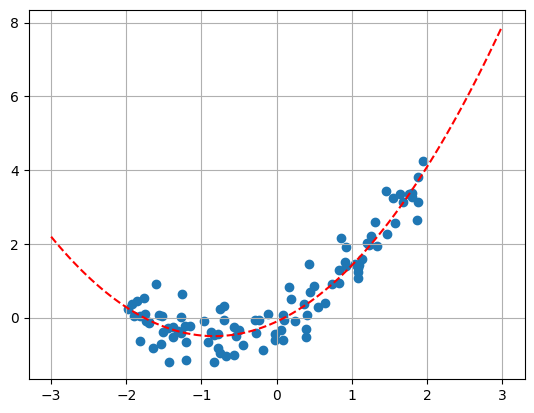

In [208]:
# 가상 데이터 생성 (y = 0.5 * x^2 + x + noise)
np.random.seed(42)
n_samples = 100
X = np.random.rand(n_samples, 1) * 4 - 2 # 약간의 비선형을 보이기 위해 임의의 값을 추가 연산
Y = 0.5 * X**2 + X + np.random.randn(n_samples, 1) * 0.5

# 2. 다항 회귀 모델 학습 (2차항)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

lin_reg = LinearRegression()
lin_reg.fit(X_poly, Y)
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.scatter(X, Y)
plt.plot(X_new, y_new, color='red', linestyle='--')
plt.grid()
